# Clustering de Texto y Perfilado de Segmentos

Las dos clases anteriores trabajaron siempre con **números**. Pero muchas
fuentes de datos son texto libre (comentarios, reseñas, tickets de soporte),
y el texto no se puede agrupar directamente: no existe una "distancia"
entre dos oraciones hasta que las convertimos en números.

Hoy vemos cómo vectorizar texto, agruparlo, y —algo que aplica tanto a
texto como a datos numéricos— cómo convertir el resultado de un clustering
en algo fácil de leer: una **etiqueta corta** por segmento, en vez de solo
un número de cluster.

Contenido de hoy:
1. De texto a números: Bag of Words y TF-IDF
2. Clustering sobre texto vectorizado
3. Términos más relevantes por cluster
4. Generar automáticamente un nombre corto por segmento (texto y numérico)
5. Tablas de contingencia entre dos variables categóricas/de cluster

In [1]:
%pip install numpy pandas matplotlib scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster                 import KMeans
from sklearn.decomposition           import TruncatedSVD
from sklearn.preprocessing           import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42
rng  = np.random.default_rng(seed=SEED)

---
## 1. Generación de un corpus sintético: reseñas de películas

Construimos reseñas combinando frases de tres "temas" distintos: actuación,
guion/ritmo, y efectos visuales/acción. El objetivo del clustering será
descubrir esos tres temas **sin que la categoría se le diga al modelo** —
la columna `tema_real` se guarda aparte solo para verificar el resultado al
final, igual que hicimos en la Clase 1 con el ejemplo de escalado.

In [3]:
plantillas_actuacion = [
    "la actuacion del protagonista es excelente y convincente",
    "la actuacion del reparto transmite emociones genuinas",
    "la actuacion del elenco es sobresaliente en cada papel",
    "la actuacion principal es lo mas destacado de la cinta",
    "la actuacion secundaria tambien aporta mucho carisma",
    "la actuacion del protagonista resulta memorable",
    "la actuacion conjunta del reparto se siente autentica",
    "la actuacion logra que cada personaje se sienta real",
]
plantillas_guion = [
    "el guion resulta predecible y carece de sorpresas",
    "el guion tiene vacios argumentales que no se explican",
    "el guion maneja un ritmo demasiado lento",
    "el guion se vuelve repetitivo conforme avanza la trama",
    "el guion ofrece un desenlace confuso y poco satisfactorio",
    "el guion incluye dialogos forzados y poco naturales",
    "el guion pierde fuerza hacia el tramo final",
    "el guion carece de un desarrollo narrativo solido",
]
plantillas_efectos = [
    "los efectos especiales resultan impresionantes y realistas",
    "los efectos visuales acompanan muy bien las secuencias de accion",
    "los efectos digitales logran tomas espectaculares",
    "los efectos construyen un mundo visualmente impresionante",
    "los efectos mantienen la adrenalina constante en cada secuencia",
    "los efectos elevan la experiencia en pantalla grande",
    "los efectos se combinan perfectamente con la banda sonora",
    "los efectos hacen de esta produccion algo sobresaliente",
]
categorias = {
    "actuacion": plantillas_actuacion,
    "guion"    : plantillas_guion,
    "efectos"  : plantillas_efectos,
}
generos_por_categoria = {
    "actuacion": ["Drama", "Drama", "Comedia", "Accion"],
    "guion"    : ["Drama", "Comedia", "Accion", "Drama"],
    "efectos"  : ["Accion", "Accion", "Comedia", "Drama"],
}

textos, tema_real, genero_pelicula = [], [], []
for nombre_cat, plantillas in categorias.items():
    for _ in range(30):
        n_frases = rng.integers(1, 3)
        frases   = rng.choice(plantillas, size=n_frases, replace=False)
        textos.append(". ".join(frases).capitalize() + ".")
        tema_real.append(nombre_cat)
        genero_pelicula.append(rng.choice(generos_por_categoria[nombre_cat]))

df_resenas = pd.DataFrame({
    "texto_resena"   : textos,
    "tema_real"      : tema_real,        # solo para verificar al final
    "genero_pelicula": genero_pelicula,  # variable categórica para la sección 5
})
print(f"Corpus generado: {len(df_resenas)} reseñas")
df_resenas.sample(5, random_state=SEED)

Corpus generado: 90 reseñas


,texto_resena,tema_real,genero_pelicula
40,El guion se vuelve repetitivo conforme avanza ...,guion,Comedia
22,La actuacion del protagonista es excelente y c...,actuacion,Accion
55,El guion incluye dialogos forzados y poco natu...,guion,Comedia
70,Los efectos digitales logran tomas espectacula...,efectos,Drama
0,La actuacion conjunta del reparto se siente au...,actuacion,Comedia


---
## 2. De texto a números

### 2.1 Limpieza básica de texto

Antes de vectorizar conviene normalizar el texto: minúsculas, sin signos de
puntuación, y quitar **stopwords** (palabras muy frecuentes que aportan poco
significado: artículos, preposiciones, conjunciones). `scikit-learn` no trae
una lista de stopwords en español por defecto, así que se define a mano.

In [4]:
import re

STOPWORDS_ES = [
    "el", "la", "los", "las", "de", "del", "y", "en", "es", "un", "una", "unos", "unas",
    "que", "se", "con", "por", "para", "muy", "mas", "su", "sus", "lo", "al", "tiene",
    "tienen", "hay", "ha", "han", "esta", "este", "estas", "estos", "como", "pero",
    "tambien", "son", "ser", "fue", "le", "les", "o", "u", "e", "ni", "sin", "sobre",
    "ya", "que", "cada", "entre", "hacia", "desde",
]

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df_resenas["texto_limpio"] = df_resenas["texto_resena"].apply(limpiar_texto)
df_resenas[["texto_resena", "texto_limpio"]].head(3)

,texto_resena,texto_limpio
0,La actuacion conjunta del reparto se siente au...,la actuacion conjunta del reparto se siente au...
1,La actuacion principal es lo mas destacado de ...,la actuacion principal es lo mas destacado de ...
2,La actuacion del protagonista resulta memorable.,la actuacion del protagonista resulta memorable


### 2.2 Bag of Words vs. TF-IDF

- **Bag of Words** (`CountVectorizer`): cuenta cuántas veces aparece cada
  palabra en cada documento. Trata todas las palabras frecuentes con el
  mismo peso, sin importar si aparecen en casi todos los documentos.
- **TF-IDF** (`TfidfVectorizer`): además de contar, **penaliza** las palabras
  que aparecen en muchos documentos distintos (poco distintivas) y
  **resalta** las que aparecen mucho en pocos documentos (muy distintivas).

In [5]:
vectorizador_bow = CountVectorizer(stop_words=STOPWORDS_ES)
matriz_bow = vectorizador_bow.fit_transform(df_resenas["texto_limpio"])

vectorizador_tfidf = TfidfVectorizer(stop_words=STOPWORDS_ES)
matriz_tfidf = vectorizador_tfidf.fit_transform(df_resenas["texto_limpio"])

print(f"Vocabulario: {len(vectorizador_tfidf.get_feature_names_out())} palabras distintas")
print(f"Matriz Bag of Words: {matriz_bow.shape}  (filas=reseñas, columnas=vocabulario)")
print(f"Matriz TF-IDF       : {matriz_tfidf.shape}")

Vocabulario: 93 palabras distintas
Matriz Bag of Words: (90, 93)  (filas=reseñas, columnas=vocabulario)
Matriz TF-IDF       : (90, 93)


In [6]:
# En vez de asumir qué palabras son comunes o distintivas, las identificamos
# con código: la que aparece en más reseñas distintas (poco distintiva) y
# una de las que aparece en menos reseñas (potencialmente más distintiva).
vocabulario = vectorizador_tfidf.get_feature_names_out()
frecuencia_documentos = np.asarray((matriz_bow > 0).sum(axis=0)).ravel()

idx_mas_comun       = frecuencia_documentos.argmax()
idx_menos_frecuente = np.where(frecuencia_documentos == frecuencia_documentos.min())[0][0]

for etiqueta, idx in [("más común", idx_mas_comun), ("menos frecuente", idx_menos_frecuente)]:
    palabra         = vocabulario[idx]
    peso_bow_prom   = matriz_bow[:, idx].toarray().mean()
    peso_tfidf_prom = matriz_tfidf[:, idx].toarray().mean()
    print(f"'{palabra}' ({etiqueta}, en {frecuencia_documentos[idx]} reseñas): "
          f"promedio BoW = {peso_bow_prom:.3f}   |   promedio TF-IDF = {peso_tfidf_prom:.3f}")

# TF-IDF reduce el peso relativo de palabras comunes a todos los temas
# (como "pelicula") y conserva un peso más alto en palabras distintivas
# de un solo tema (como "efectos") — por eso suele dar mejores resultados
# de clustering que Bag of Words.

'actuacion' (más común, en 30 reseñas): promedio BoW = 0.500   |   promedio TF-IDF = 0.122
'logra' (menos frecuente, en 3 reseñas): promedio BoW = 0.033   |   promedio TF-IDF = 0.015


---
## 3. Clustering sobre texto vectorizado

Aplicamos K-Means directamente sobre la matriz TF-IDF (cada fila es una
reseña representada por cientos de columnas, una por palabra del
vocabulario). Para poder graficar el resultado, reducimos a 2 dimensiones
con **`TruncatedSVD`** — similar a PCA, pero funciona directamente sobre
matrices dispersas como las que produce TF-IDF, sin tener que convertirlas
primero a una matriz densa.

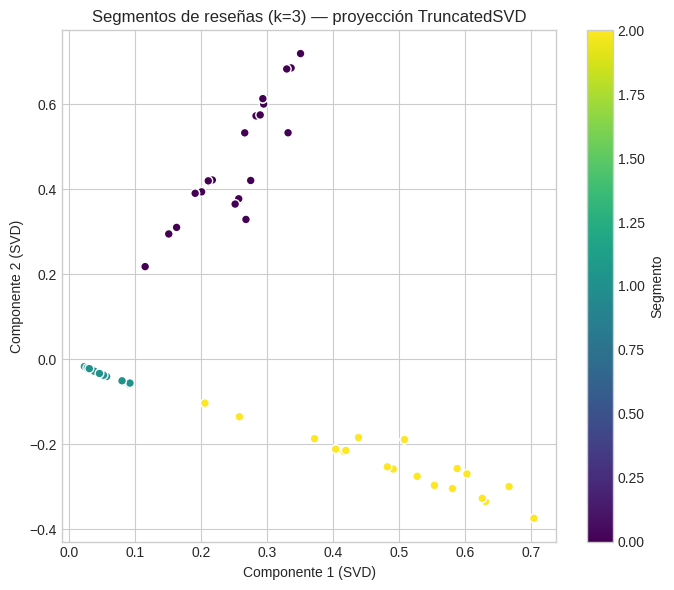

In [7]:
K_TEXTO = 3
modelo_texto = KMeans(n_clusters=K_TEXTO, n_init=10, random_state=SEED)
df_resenas["segmento_texto"] = modelo_texto.fit_predict(matriz_tfidf)

svd = TruncatedSVD(n_components=2, random_state=SEED)
coordenadas_2d = svd.fit_transform(matriz_tfidf)

fig, ax = plt.subplots(figsize=(7, 6))
dispersión = ax.scatter(coordenadas_2d[:, 0], coordenadas_2d[:, 1],
                         c=df_resenas["segmento_texto"], cmap="viridis", s=40, edgecolor="white")
ax.set_xlabel("Componente 1 (SVD)")
ax.set_ylabel("Componente 2 (SVD)")
ax.set_title(f"Segmentos de reseñas (k={K_TEXTO}) — proyección TruncatedSVD")
plt.colorbar(dispersión, ax=ax, label="Segmento")
plt.tight_layout()
plt.show()

In [8]:
# Verificación: como en este ejemplo sintético sí conocemos el tema real de
# cada reseña, podemos confirmar que el clustering recuperó los tres temas.
pd.crosstab(df_resenas["tema_real"], df_resenas["segmento_texto"])

segmento_texto,0,1,2
tema_real,,,
actuacion,0,0,30
efectos,0,30,0
guion,30,0,0


---
## 4. Términos más relevantes por cluster

Para entender de qué habla cada segmento, se calcula el peso promedio de
TF-IDF de cada palabra **dentro de ese cluster** y se muestran las palabras
con mayor peso. Esto reemplaza a una nube de palabras cuando no se cuenta
con esa librería instalada — la información es la misma, solo cambia la
forma de mostrarla.

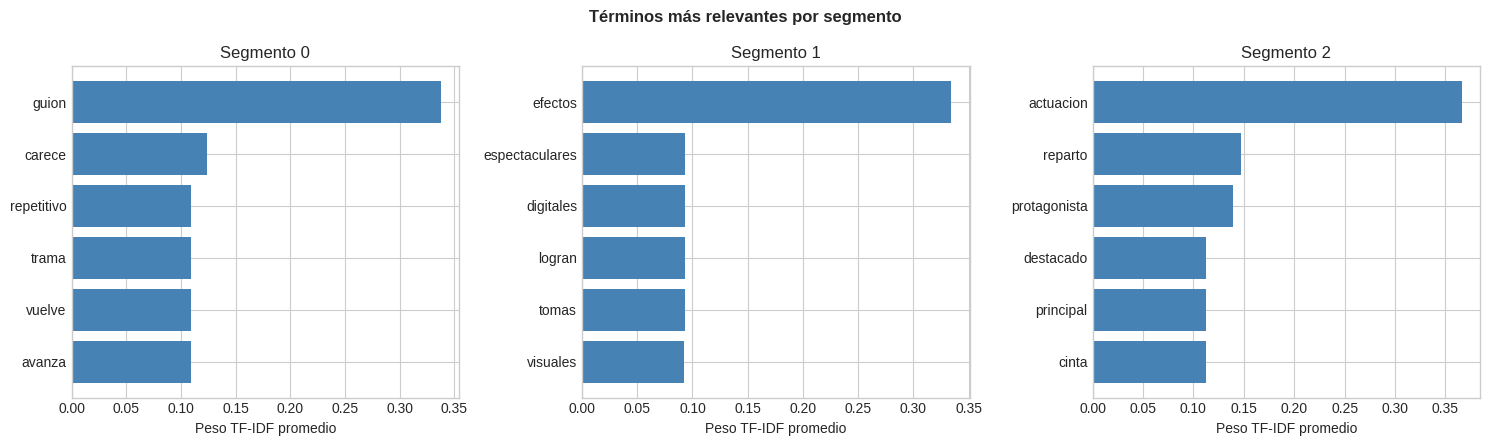

In [9]:
def terminos_top_por_cluster(matriz_tfidf, vocabulario, etiquetas_cluster, n_terminos=6):
    resultado = {}
    for cluster_id in sorted(set(etiquetas_cluster)):
        filas_cluster  = matriz_tfidf[etiquetas_cluster == cluster_id]
        peso_promedio  = np.asarray(filas_cluster.mean(axis=0)).ravel()
        indices_top    = peso_promedio.argsort()[::-1][:n_terminos]
        resultado[cluster_id] = [(vocabulario[i], peso_promedio[i]) for i in indices_top]
    return resultado

terminos_por_segmento = terminos_top_por_cluster(
    matriz_tfidf, vocabulario, df_resenas["segmento_texto"].values
)

fig, axes = plt.subplots(1, K_TEXTO, figsize=(15, 4.5))
for ax, (cluster_id, terminos) in zip(axes, terminos_por_segmento.items()):
    palabras, pesos = zip(*terminos)
    ax.barh(palabras[::-1], pesos[::-1], color="steelblue")
    ax.set_title(f"Segmento {cluster_id}")
    ax.set_xlabel("Peso TF-IDF promedio")
plt.suptitle("Términos más relevantes por segmento", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5. Nombre corto automático por segmento

Un número de cluster ("Segmento 0") no dice nada por sí solo. Con la misma
información que ya calculamos (palabras top en texto; promedios por
variable en datos numéricos) podemos generar una **etiqueta corta** de
forma totalmente mecánica, sin redactar nada a mano.

### 5.1 Nombre corto para clusters de texto
Se toman directamente las 1-2 palabras con mayor peso promedio del cluster.

In [10]:
def nombre_corto_texto(terminos_por_cluster, n_terminos=2):
    nombres = {}
    for cluster_id, terminos in terminos_por_cluster.items():
        palabras = [palabra for palabra, _ in terminos[:n_terminos]]
        nombres[cluster_id] = " / ".join(p.capitalize() for p in palabras)
    return nombres

nombres_segmentos_texto = nombre_corto_texto(terminos_por_segmento)
for cluster_id, nombre in nombres_segmentos_texto.items():
    cantidad = (df_resenas["segmento_texto"] == cluster_id).sum()
    print(f"Segmento {cluster_id} → \"{nombre}\"  ({cantidad} reseñas)")

Segmento 0 → "Guion / Carece"  (30 reseñas)
Segmento 1 → "Efectos / Espectaculares"  (30 reseñas)
Segmento 2 → "Actuacion / Reparto"  (30 reseñas)


### 5.2 Nombre corto para clusters numéricos

La misma idea aplicada a datos numéricos: para cada variable se calcula
qué tan lejos está el promedio del cluster respecto al promedio global (en
desviaciones estándar), y se toman las 1-2 variables más distintivas.
Lo aplicamos sobre un dataset nuevo y pequeño: presupuesto, duración y
calificación de películas, agrupadas en tres perfiles típicos de la industria.

In [11]:
N_PELICULAS = 150
perfiles_pelicula = {
    "blockbuster":   dict(duracion=140, presupuesto=180, calificacion=6.8),
    "independiente": dict(duracion=95,  presupuesto=5,   calificacion=7.2),
    "drama_clasico": dict(duracion=115, presupuesto=40,  calificacion=7.6),
}
tipo_real_pelicula = rng.choice(list(perfiles_pelicula.keys()), size=N_PELICULAS)

filas = []
for tipo in tipo_real_pelicula:
    p = perfiles_pelicula[tipo]
    filas.append({
        "duracion_minutos"    : max(60, rng.normal(p["duracion"], 12)),
        "presupuesto_millones": max(0.5, rng.normal(p["presupuesto"], 20)),
        "calificacion_imdb"   : np.clip(rng.normal(p["calificacion"], 0.7), 1, 10),
    })

df_peliculas    = pd.DataFrame(filas)
columnas_pelicula = df_peliculas.columns.tolist()

scaler_peliculas = StandardScaler()
X_peliculas      = scaler_peliculas.fit_transform(df_peliculas[columnas_pelicula])
df_peliculas["segmento"] = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit_predict(X_peliculas)

In [12]:
def nombre_corto_numerico(df, columnas, etiquetas_cluster, n_terminos=2):
    promedio_global   = df[columnas].mean()
    desviacion_global = df[columnas].std()
    nombres = {}
    for cluster_id in sorted(etiquetas_cluster.unique()):
        promedio_cluster = df.loc[etiquetas_cluster == cluster_id, columnas].mean()
        z_scores = (promedio_cluster - promedio_global) / desviacion_global
        top = z_scores.abs().sort_values(ascending=False).head(n_terminos)
        partes = []
        for col in top.index:
            direccion = "Alto" if z_scores[col] > 0 else "Bajo"
            partes.append(f"{direccion} {col.replace('_', ' ')}")
        nombres[cluster_id] = " / ".join(partes)
    return nombres

nombres_segmentos_peliculas = nombre_corto_numerico(df_peliculas, columnas_pelicula, df_peliculas["segmento"])
for cluster_id, nombre in nombres_segmentos_peliculas.items():
    cantidad = (df_peliculas["segmento"] == cluster_id).sum()
    print(f"Segmento {cluster_id} → \"{nombre}\"  ({cantidad} películas)")

Segmento 0 → "Alto presupuesto millones / Alto duracion minutos"  (54 películas)
Segmento 1 → "Bajo duracion minutos / Bajo presupuesto millones"  (55 películas)
Segmento 2 → "Alto calificacion imdb / Bajo presupuesto millones"  (41 películas)


In [13]:
# Caso borde: si un cluster queda cerca del promedio en todo, conviene un
# nombre de respaldo en vez de forzar una etiqueta poco representativa.
UMBRAL_Z_MINIMO = 0.3

def nombre_corto_numerico_con_respaldo(df, columnas, etiquetas_cluster, n_terminos=2):
    promedio_global   = df[columnas].mean()
    desviacion_global = df[columnas].std()
    nombres = {}
    for cluster_id in sorted(etiquetas_cluster.unique()):
        promedio_cluster = df.loc[etiquetas_cluster == cluster_id, columnas].mean()
        z_scores = (promedio_cluster - promedio_global) / desviacion_global
        top = z_scores.abs().sort_values(ascending=False).head(n_terminos)
        if top.iloc[0] < UMBRAL_Z_MINIMO:
            nombres[cluster_id] = "Segmento Promedio"
            continue
        partes = [f"{'Alto' if z_scores[c] > 0 else 'Bajo'} {c.replace('_', ' ')}" for c in top.index]
        nombres[cluster_id] = " / ".join(partes)
    return nombres

---
## 6. Tablas de contingencia (relacionar dos variables categóricas)

Cuando existen dos columnas categóricas relacionadas con las mismas filas
(por ejemplo, una etiqueta de cluster y otra variable categórica ya
existente en los datos), una **tabla de contingencia** muestra cuántas
observaciones caen en cada combinación de las dos. Es la forma más directa
de revisar si dos agrupamientos distintos están relacionados entre sí.

In [14]:
# Conteos absolutos: cuántas reseñas de cada género caen en cada segmento de texto.
tabla_conteos = pd.crosstab(df_resenas["genero_pelicula"], df_resenas["segmento_texto"])
print("Conteos:")
print(tabla_conteos)

Conteos:
segmento_texto    0   1   2
genero_pelicula            
Accion            9  14  10
Comedia           8   5   7
Drama            13  11  13


In [15]:
# Porcentajes por fila: de las reseñas de cada género, qué porcentaje cae en cada segmento.
tabla_porcentajes = pd.crosstab(
    df_resenas["genero_pelicula"], df_resenas["segmento_texto"], normalize="index"
).round(3) * 100
print("\nPorcentaje por género (filas suman 100%):")
print(tabla_porcentajes)

# Esta misma operación —cruzar una etiqueta de cluster contra otra variable
# categórica ya existente en los datos— es la base de cualquier análisis que
# busque relacionar dos resultados de clustering obtenidos de fuentes
# distintas, usando una columna en común entre ambas tablas.


Porcentaje por género (filas suman 100%):
segmento_texto      0     1     2
genero_pelicula                  
Accion           27.3  42.4  30.3
Comedia          40.0  25.0  35.0
Drama            35.1  29.7  35.1


---
## Resumen General — Clustering (Clases 1, 2 y 3)

| Técnica | Clase | Para qué sirve |
|---|---|---|
| `KMeans` | 1 | Agrupar datos numéricos en `k` clusters |
| Método del codo | 1 | Guía para elegir `k` a partir de la inercia |
| `StandardScaler` | 1 | Evitar que una variable domine la distancia por su escala |
| `PCA` | 1 | Visualizar datos de muchas variables en 2D |
| `DBSCAN` | 2 | Clusters de forma arbitraria + detección de ruido |
| `AgglomerativeClustering` / dendrograma | 2 | Clustering jerárquico y su visualización |
| Silhouette / Davies-Bouldin / Calinski-Harabasz | 2 | Evaluar la calidad de un clustering sin etiquetas |
| `predict()` / KNN sobre etiquetas | 2 | Asignar un dato nuevo a un cluster ya entrenado |
| `joblib` | 2 | Persistir el modelo entrenado |
| `CountVectorizer` / `TfidfVectorizer` | 3 | Convertir texto en una matriz numérica |
| `TruncatedSVD` | 3 | Visualizar clusters de texto en 2D |
| Términos top por TF-IDF | 3 | Interpretar de qué habla cada cluster de texto |
| Nombre corto por z-score / por término top | 3 | Etiquetar un segmento sin redactar a mano |
| `pd.crosstab` | 3 | Relacionar dos variables categóricas o dos resultados de cluster |